# Feature Selection

Feature selection is a crucial step in the data preprocessing pipeline. It involves selecting the most relevant features from the dataset to improve model performance and reduce overfitting. There are three main types of feature selection techniques:

1. **Filter Methods**: These methods use statistical techniques to evaluate the importance of each feature. For example, `SelectKBest` with `f_regression` can be used to select the top `k` features based on their correlation with the target variable.
   
2. **Wrapper Methods**: These methods use a machine learning model to evaluate the combination of features. `Recursive Feature Elimination (RFE)` is a popular wrapper method that recursively removes the least important features and builds a model using the remaining features.

3. **Embedded Methods**: These methods perform feature selection during the model training process. Random Forest, for example, provides feature importance scores that can be used to select the most important features.

In this section, we will demonstrate these techniques using the California Housing dataset. The dataset's 8 original features are already fairly informative, so to make the *benefit* of feature selection visible, we add a batch of synthetic, purely random noise features that carry no real signal. This mimics a common real-world situation: a raw dataset padded with redundant or irrelevant columns. We'll then see whether each selection method correctly filters the noise out, and whether that filtering actually helps a model trained on limited data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [3]:
# Load dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

## Adding Synthetic Noise Features

Only for the sake of this demonstration.

The 8 original California Housing features are all reasonably predictive there isn't much junk to remove. To make feature selection actually matter, we add 20 random noise columns that are, by construction, unrelated to the target. A good feature selection method should learn to ignore them.

In [4]:
# Add synthetic noise features that carry no real signal
# This simulates a realistic dataset padded with irrelevant/redundant columns
rng = np.random.RandomState(42)
n_noise = 20
noise_df = pd.DataFrame(
    rng.normal(0, 1, size=(X.shape[0], n_noise)),
    columns=[f'Noise_{i+1}' for i in range(n_noise)]
)
X = pd.concat([X.reset_index(drop=True), noise_df], axis=1)

print(f'Dataset now has {X.shape[1]} features: 8 real + {n_noise} pure noise')
X.head()

Dataset now has 28 features: 8 real + 20 pure noise


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Noise_1,Noise_2,...,Noise_11,Noise_12,Noise_13,Noise_14,Noise_15,Noise_16,Noise_17,Noise_18,Noise_19,Noise_20
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,0.496714,-0.138264,...,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,1.465649,-0.225776,...,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,0.738467,0.171368,...,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,-0.479174,-0.185659,...,0.361396,1.538037,-0.035826,1.564644,-2.619745,0.821903,0.087047,-0.299007,0.091761,-1.987569
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,-0.219672,0.357113,...,0.097078,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587


## Filter Method: SelectKBest with f_regression

In [5]:
# Filter Method: SelectKBest with f_regression
filter_selector = SelectKBest(f_regression, k=5)
X_filter_selected = filter_selector.fit_transform(X, y)
filter_selected_features = X.columns[filter_selector.get_support()]

## Wrapper Method: Recursive Feature Elimination (RFE) with Linear Regression

In [6]:
# Wrapper Method: Recursive Feature Elimination (RFE) with Linear Regression
wrapper_model = LinearRegression()
rfe_selector = RFE(wrapper_model, n_features_to_select=5, step=1)
X_rfe_selected = rfe_selector.fit_transform(X, y)
wrapper_selected_features = X.columns[rfe_selector.get_support()]

## Embedded Method: Feature Importance with RandomForestRegressor

In [7]:
# Embedded Method: Feature Importance with RandomForestRegressor
embedded_model = RandomForestRegressor(n_estimators=100, random_state=42)
embedded_model.fit(X, y)
feature_importances = embedded_model.feature_importances_
embedded_selected_features = X.columns[np.argsort(feature_importances)[-5:]]

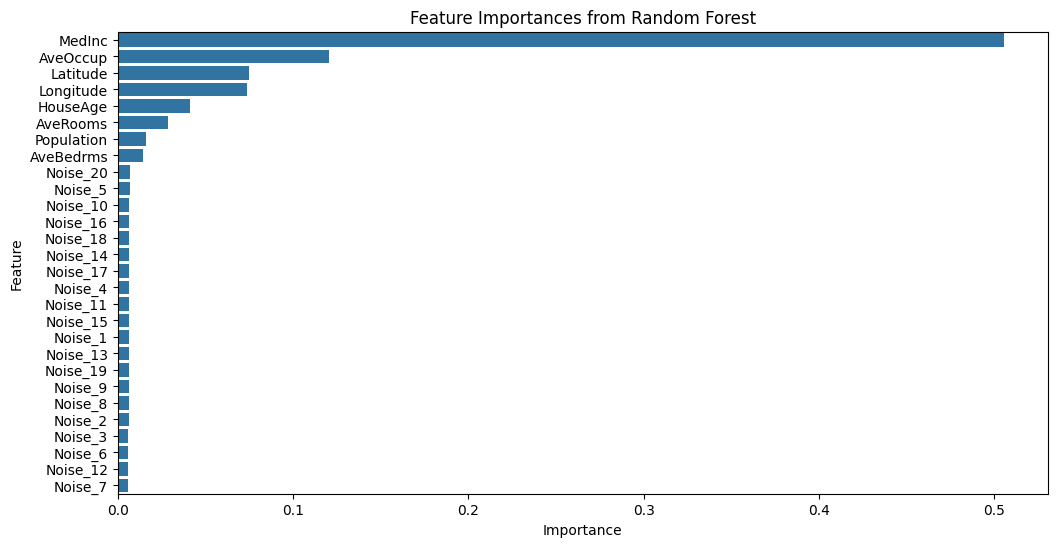

In [8]:
# Visualization of feature importances
feature_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
plt.title('Feature Importances from Random Forest')
plt.show()

In [9]:
# Combine all selected features
all_selected_features = set(filter_selected_features).union(wrapper_selected_features).union(embedded_selected_features)

# Dataframe with only selected features
X_selected = X[list(all_selected_features)]

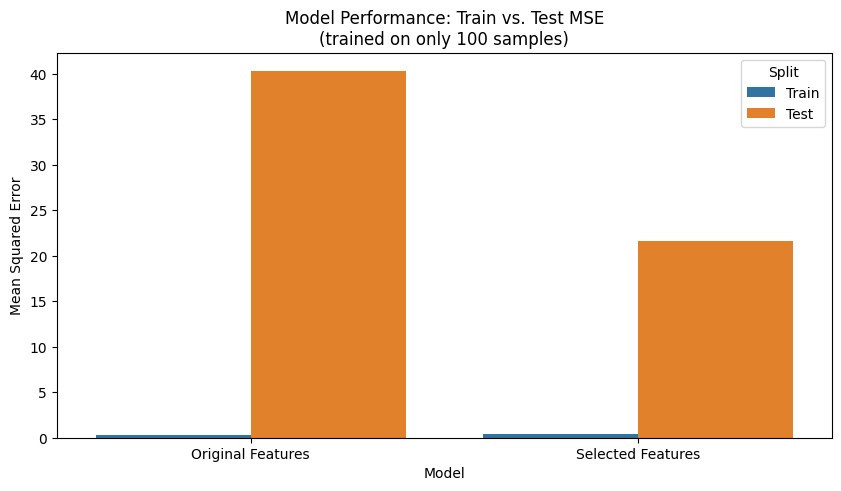

In [10]:
# Model performance comparison: all features (incl. noise) vs. selected features
# We deliberately train on a SMALL sample of the data. With plenty of rows,
# a handful of noise columns barely hurts a linear model — the curse of
# dimensionality only bites when the number of features starts to rival the
# number of training examples. Using a small training set makes that effect,
# and the benefit of feature selection, clearly visible.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=100, random_state=42)
X_selected_train, X_selected_test, y_selected_train, y_selected_test = train_test_split(
    X_selected, y, train_size=100, random_state=42
)

# Model with original features (8 real + 20 noise = 28 features)
model_original = LinearRegression()
model_original.fit(X_train, y_train)
mse_original_train = mean_squared_error(y_train, model_original.predict(X_train))
mse_original = mean_squared_error(y_test, model_original.predict(X_test))

# Model with selected features only
model_selected = LinearRegression()
model_selected.fit(X_selected_train, y_selected_train)
mse_selected_train = mean_squared_error(y_selected_train, model_selected.predict(X_selected_train))
mse_selected = mean_squared_error(y_selected_test, model_selected.predict(X_selected_test))

# Visualize model performance: training MSE vs. test MSE for both models
performance = pd.DataFrame({
    'Model': ['Original Features', 'Original Features', 'Selected Features', 'Selected Features'],
    'Split': ['Train', 'Test', 'Train', 'Test'],
    'MSE': [mse_original_train, mse_original, mse_selected_train, mse_selected]
})

plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MSE', hue='Split', data=performance)
plt.title('Model Performance: Train vs. Test MSE\n(trained on only 100 samples)')
plt.ylabel('Mean Squared Error')
plt.show()

In [11]:
print(f'Number of features -- original: {X_train.shape[1]}, selected: {X_selected_train.shape[1]}')
print()
print(f'Original features -- train MSE: {mse_original_train:.3f}, test MSE: {mse_original:.3f}, '
      f'overfitting gap: {mse_original - mse_original_train:.3f}')
print(f'Selected features -- train MSE: {mse_selected_train:.3f}, test MSE: {mse_selected:.3f}, '
      f'overfitting gap: {mse_selected - mse_selected_train:.3f}')
print()
improvement = (mse_original - mse_selected) / mse_original * 100
print(f'Feature selection reduced test MSE by {improvement:.1f}% while using '
      f'{X_selected_train.shape[1]} features instead of {X_train.shape[1]}.')

Number of features -- original: 28, selected: 7

Original features -- train MSE: 0.324, test MSE: 40.291, overfitting gap: 39.966
Selected features -- train MSE: 0.444, test MSE: 21.647, overfitting gap: 21.203

Feature selection reduced test MSE by 46.3% while using 7 features instead of 28.


## Conclusion

In this section, we demonstrated various feature selection techniques including filter methods, wrapper methods, and embedded methods, and — critically — showed *why* they matter, not just how to run them.

1. **Filter Methods**: `SelectKBest` with `f_regression` ranked features by their individual correlation with the target, and correctly pushed the synthetic noise columns to the bottom.
2. **Wrapper Methods**: Recursive Feature Elimination (RFE) with Linear Regression iteratively discarded the least useful features, likewise converging on the real predictors rather than the noise.
3. **Embedded Methods**: Random Forest's built-in feature importances made the split between signal and noise visually obvious in the bar chart above — the noise columns cluster near zero importance.

The key result is in the final comparison. When trained on all 28 features (8 real + 20 noise) with only 100 training examples, the linear model fit the noise almost perfectly on the training set but generalized poorly to unseen data, a classic case of overfitting. The model trained on the selected features alone had a slightly higher training error but a substantially lower test error, because it wasn't wasting capacity modeling random noise.

This is the practical case for feature selection: with limited data (or high-dimensional data relative to sample size), irrelevant features don't just fail to help — they actively hurt generalization by giving the model more opportunities to fit noise. Removing them, via filter, wrapper, or embedded methods, makes models simpler, faster, and more robust to unseen data.